Current working directory: /home/ubu/Desktop/Michael/lazyMapping_Prober/stable/python
✓ Found stable directory: /home/ubu/Desktop/Michael/lazyMapping_Prober/stable
Data directory: /home/ubu/Desktop/Michael/lazyMapping_Prober/stable/data

Computing mean memorygrams from CSV files for all configs

[Config 1] Checking path: /home/ubu/Desktop/Michael/lazyMapping_Prober/stable/data/chrome_clock/1C_2TST_90K_1144cycles
  Scanning: /home/ubu/Desktop/Michael/lazyMapping_Prober/stable/data/chrome_clock/1C_2TST_90K_1144cycles
    ✓ bsearch: 50 samples, mean=5750858.25
    ✓ bsearch_max: 50 samples, mean=5476326.08
    ✓ cache: 50 samples, mean=4073215.11
    ✓ heapsort: 50 samples, mean=5537083.16
    ✓ heapsort_max: 50 samples, mean=4185044.10
    ✓ hsearch: 50 samples, mean=4286116.18
    ✓ hsearch_max: 50 samples, mean=3318024.43
    ✓ judy: 50 samples, mean=3126442.44
    ✓ judy_max: 50 samples, mean=2899799.38
    ✓ lockbus: 50 samples, mean=2418363.23
    ✓ lsearch: 50 samples, mean=5900577

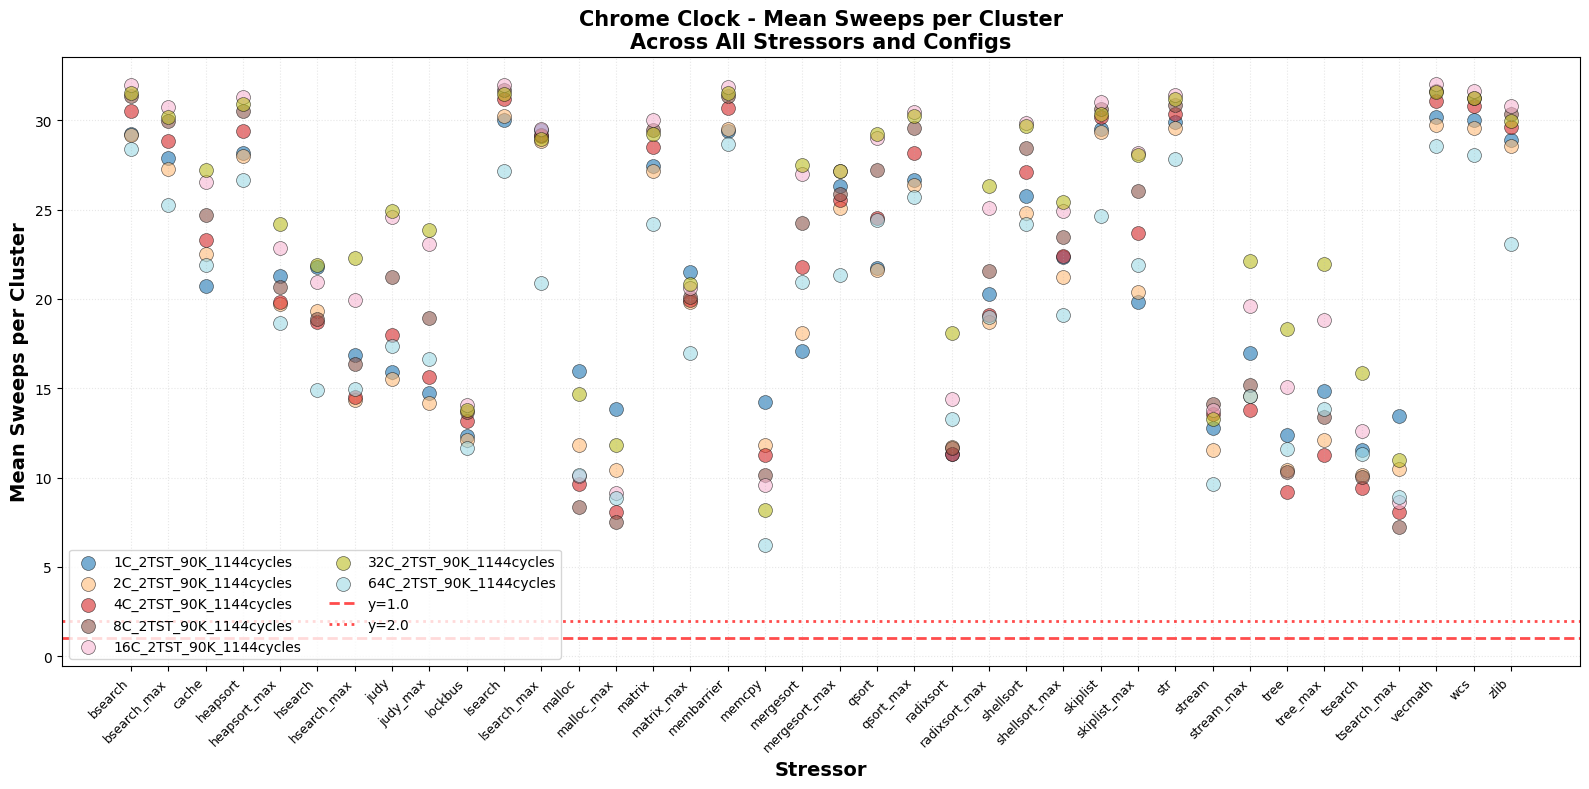


Mean Sweeps per Cluster Analysis Complete
Formula: mean_sweepsNum = stressor_mean / (totalsets/config * associativity)
where totalsets=16384, associativity=12


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from pathlib import Path
import os

TOTALSETS = 2**14  # 16384
ASSOCIATIVITY = 12
CONFIGS = [1, 2, 4, 8, 16, 32, 64]
all_chrome_means = {}  # {config_name: {stressor: mean_value}}
all_config_ratios = {}
common_stressors_all = None  # Initialize this!

# ==========================================
# Find the correct data directory
# ==========================================
print(f"Current working directory: {os.getcwd()}")

# Find the 'stable' directory by searching upward from current location
current_dir = Path.cwd()
stable_dir = None

# First check if we're already in stable or a subdirectory of it
for parent in [current_dir] + list(current_dir.parents):
    if (parent / "data").exists() and (parent / "data" / "chrome_clock").exists():
        stable_dir = parent
        print(f"✓ Found stable directory: {stable_dir}")
        break

if stable_dir is None:
    # Fallback to hardcoded path
    stable_dir = Path("/home/ubu/Desktop/Michael/lazyMapping_Prober/stable")
    print(f"⚠ Using fallback path: {stable_dir}")

if not stable_dir.exists():
    raise FileNotFoundError(f"Could not find stable directory. Checked: {stable_dir}")

DATA_DIR = stable_dir / "data"
print(f"Data directory: {DATA_DIR}\n")


def compute_stressor_means_from_csv(config_path):
    """
    For a given config path, compute the mean memorygram for each stressor from CSV files.
    
    Args:
        config_path: full Path object to config directory
    
    Returns:
        stressor_means: dict {stressor_name: mean_value_per_stressor}
    """
    stressor_means = {}
    config_path = Path(config_path)
    
    if not config_path.exists():
        print(f"⚠ Path does not exist: {config_path}")
        return None
    
    print(f"  Scanning: {config_path}")
    
    # Iterate through all stressor directories
    for stressor_dir in sorted(config_path.iterdir()):
        if not stressor_dir.is_dir():
            continue
        
        stressor_name = stressor_dir.name
        all_values = []
        sample_count = 0
        
        # Read all CSV files for this stressor (0.csv, 1.csv, 2.csv, ...)
        for csv_file in sorted(stressor_dir.glob("*.csv")):
            try:
                df = pd.read_csv(csv_file)
                # Flatten all values (all rows and columns) and append
                all_values.extend(df.values.flatten().tolist())
                sample_count += 1
            except Exception as e:
                print(f"    ⚠ Error reading {csv_file}: {e}")
                continue
        
        # Compute mean across all values for this stressor
        if all_values:
            mean_value = np.mean(all_values)
            stressor_means[stressor_name] = mean_value
            print(f"    ✓ {stressor_name}: {sample_count} samples, mean={mean_value:.2f}")
    
    return stressor_means if stressor_means else None


def calculate_mean_sweeps(means_dict, config_value):
    """
    Calculate mean sweeps per cluster for a given config.
    
    Args:
        means_dict: dict of {stressor: mean_value}
        config_value: number of clusters (e.g., 1, 2, 4, ...)
    
    Returns:
        dict of {stressor: mean_sweeps_num}
    """
    setsPerCluster = TOTALSETS / config_value
    sweeps = {}
    
    for stressor, mean_value in means_dict.items():
        mean_sweepsNum = mean_value / (setsPerCluster * ASSOCIATIVITY)
        sweeps[stressor] = mean_sweepsNum
    
    return sweeps

# ==========================================
# Calculate Mean Sweeps per Cluster for Each Stressor
# ==========================================

print(f"Computing mean memorygrams from CSV files for all configs")
print("=" * 80)

for config in CONFIGS:
    CHROME_CONFIG_NAME = f"{config}C_2TST_90K_1144cycles"
    
    chrome_path = DATA_DIR / "chrome_clock" / CHROME_CONFIG_NAME
    print(f"\n[Config {config}] Checking path: {chrome_path}")
    chrome_means = compute_stressor_means_from_csv(chrome_path)

    if chrome_means is None:
        print(f"⚠ Skipping {CHROME_CONFIG_NAME}: no data found")
        continue
    
    # Find common stressors
    common_stressors = set(chrome_means.keys())
    common_stressors = sorted(list(common_stressors))
    
    # Store for later use (only set once)
    if common_stressors_all is None:
        common_stressors_all = common_stressors
    
    all_chrome_means[CHROME_CONFIG_NAME] = chrome_means
    print(f"✓ {CHROME_CONFIG_NAME}: {len(common_stressors)} stressors")

print(f"\n{'='*80}")
print(f"✓ Loaded {len(all_chrome_means)} configs")
print(f"{'='*80}")

# ==========================================
# Calculate Mean Sweeps per Cluster
# ==========================================

# Calculate sweeps for all configs
all_chrome_sweeps = {}  # {config_name: {stressor: sweeps}}

for config in CONFIGS:
    CHROME_CONFIG_NAME = f"{config}C_2TST_90K_1144cycles"
    
    if CHROME_CONFIG_NAME not in all_chrome_means:
        continue
    
    all_chrome_sweeps[CHROME_CONFIG_NAME] = calculate_mean_sweeps(all_chrome_means[CHROME_CONFIG_NAME], config)

print(f"Calculated sweeps for {len(all_chrome_sweeps)} configs\n")

# ==========================================
# Plot: Chrome Clock - Mean Sweeps per Stressor Across All Configs
# ==========================================

if all_chrome_sweeps:  # Only plot if we have data
    fig2, ax2 = plt.subplots(figsize=(16, 8))

    colors = plt.cm.tab20(np.linspace(0, 1, len(all_chrome_sweeps)))

    for idx, (config_name, sweeps) in enumerate(all_chrome_sweeps.items()):
        stressor_names = sorted(sweeps.keys())
        sweep_values = [sweeps[s] for s in stressor_names]
        x_pos = np.arange(len(stressor_names))
        
        ax2.scatter(x_pos, sweep_values, s=100, alpha=0.6, 
                   label=config_name, color=colors[idx], edgecolors='black', linewidth=0.5)

    # Add reference lines
    ax2.axhline(y=1.0, color='red', linestyle='--', linewidth=2, alpha=0.7, label='y=1.0')
    ax2.axhline(y=2.0, color='red', linestyle=':', linewidth=2, alpha=0.7, label='y=2.0')

    ax2.set_xlabel('Stressor', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Mean Sweeps per Cluster', fontsize=14, fontweight='bold')
    ax2.set_title('Chrome Clock - Mean Sweeps per Cluster\nAcross All Stressors and Configs', 
                  fontsize=15, fontweight='bold')

    ax2.set_xticks(np.arange(len(stressor_names)))
    ax2.set_xticklabels(stressor_names, rotation=45, ha='right', fontsize=9)
    ax2.grid(True, alpha=0.3, linestyle=':')
    ax2.legend(fontsize=10, loc='best', ncol=2)

    plt.tight_layout()
    plt.show()

    print(f"\n{'='*80}")
    print(f"Mean Sweeps per Cluster Analysis Complete")
    print(f"Formula: mean_sweepsNum = stressor_mean / (totalsets/config * associativity)")
    print(f"where totalsets={TOTALSETS}, associativity={ASSOCIATIVITY}")
    print(f"{'='*80}")
else:
    print("⚠ No data to plot. Check that CSV paths exist in data/chrome_clock/")